In [220]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import matplotlib.pyplot as plt
import kagglehub
import sklearn

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/sentiment-analysis-on-imdb-dataset-2026/sample_submission.csv
/kaggle/input/competitions/sentiment-analysis-on-imdb-dataset-2026/val.csv
/kaggle/input/competitions/sentiment-analysis-on-imdb-dataset-2026/train.csv
/kaggle/input/competitions/sentiment-analysis-on-imdb-dataset-2026/test.csv


In [221]:
!pip install scikit-learn

In [222]:
train = pd.read_csv("/kaggle/input/competitions/sentiment-analysis-on-imdb-dataset-2026/train.csv")
test = pd.read_csv("/kaggle/input/competitions/sentiment-analysis-on-imdb-dataset-2026/test.csv")
val = pd.read_csv("/kaggle/input/competitions/sentiment-analysis-on-imdb-dataset-2026/val.csv")
sample = pd.read_csv("/kaggle/input/competitions/sentiment-analysis-on-imdb-dataset-2026/sample_submission.csv")

train.head()

,review,sentiment
0,Just a note to add to the above comment. Fear ...,positive
1,one of the worst films i have seen to date. Pa...,negative
2,Crossfire is one of those films from the Forti...,positive
3,The film begins with people on Earth discoveri...,negative
4,"This was a pretty good episode. Though no ""Tra...",positive


# Data Understanding and EDA

In [223]:
display(train.shape)
display(val.shape)
display(test.shape)

(35000, 2)

(7500, 2)

(7500, 1)

In [224]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35000 entries, 0 to 34999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     35000 non-null  object
 1   sentiment  35000 non-null  object
dtypes: object(2)
memory usage: 547.0+ KB


In [225]:
train.describe()

,review,sentiment
count,35000,35000
unique,34792,2
top,"Hilarious, clean, light-hearted, and quote-wor...",positive
freq,4,17521


In [226]:
display(train.isna().sum())
display(test.isna().sum())
display(val.isna().sum())

review       0
sentiment    0
dtype: int64

review    0
dtype: int64

review       0
sentiment    0
dtype: int64

In [227]:
display(train.duplicated().sum())
display(test.duplicated().sum())
display(val.duplicated().sum())

np.int64(208)

np.int64(8)

np.int64(15)

Since the Kaggle test evaluation is ordered and index based removing rows from test data can misalign the test result submission. 

In [228]:
train.drop_duplicates(inplace=True)
val.drop_duplicates(inplace=True)
print(f"Duplicates: Train data - {train.duplicated().sum()} , Val data - {val.duplicated().sum()}")

Duplicates: Train data - 0 , Val data - 0


In [229]:
train['sentiment'].value_counts()

sentiment
positive    17456
negative    17336
Name: count, dtype: int64

<Axes: >

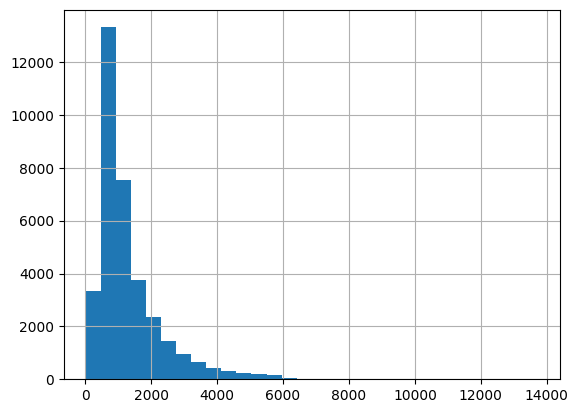

In [230]:
train['review'].str.len().hist(bins=30)

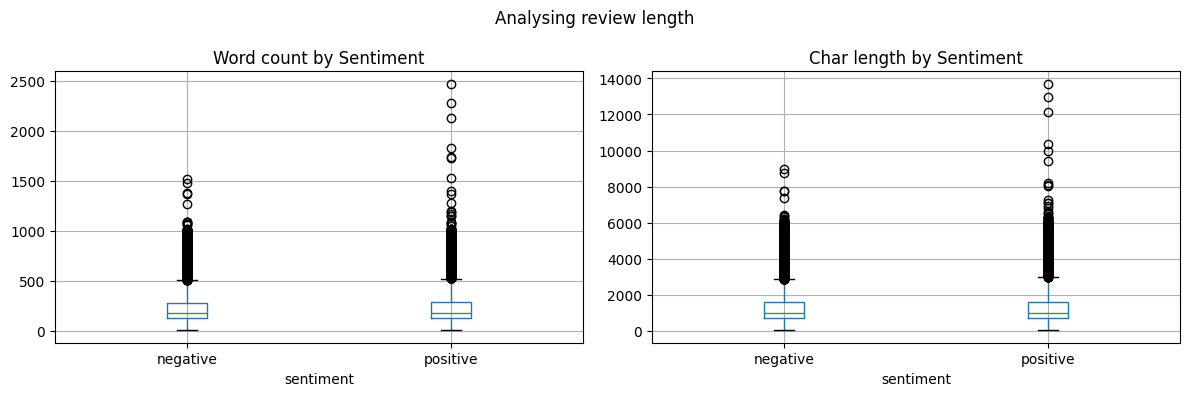

In [231]:
train['char_len'] = train['review'].str.len()
train['word_count'] = train['review'].str.split().str.len()

train.groupby('sentiment')[['char_len', 'word_count']].describe()

fig, axes = plt.subplots(1,2,figsize=(12,4))
train.boxplot(column='word_count', by='sentiment', ax=axes[0])
axes[0].set_title("Word count by Sentiment")
train.boxplot(column='char_len', by='sentiment', ax=axes[1])
axes[1].set_title("Char length by Sentiment")
plt.suptitle("Analysing review length")
plt.tight_layout()
plt.show()

In [232]:
train['review'].str.contains(r'<[^>]+>', regex=True).value_counts()

review
True     20501
False    14291
Name: count, dtype: int64

#### Summary:

- There is no missing data.
- The sentiment data is balanced.
- There are 208 duplicate rows, which is about ~0.6% of the traning dataset and 8 duplicate rows in validation dataset which is ~0.001 of the validation dataset. In both the datasets the duplicate rows are removed. 
- The word count box plot shows a median/max-whisker range averaging around 500 words, while the 
  character count box plot averages around 3,000 characters. Both plots show a number of extreme 
  outliers extending well beyond the max whisker, indicating a small number of unusually long reviews.
- Sentiment does not appear to affect review length — both the box plots and the character-length 
  histogram show similar distributions for positive and negative reviews.

### Words Analysis

In [233]:
word_pattern = r"\b[a-z]+(?:'[a-z]+)?\b"
br_pattern = r'<br\s*/?>'

In [234]:
from collections import Counter
import re

def get_word_counts(reviews, n=20):
    words = []
    for text in reviews:
        words.extend(re.findall(word_pattern, text.lower()))
    return Counter(words).most_common(n)

print("Top words - positive reviews:")
print(get_word_counts(train[train['sentiment'] == 'positive']['review']))

print("\nTop words - negative reviews:")
print(get_word_counts(train[train['sentiment'] == 'negative']['review']))

Top words - positive reviews:
[('the', 239478), ('and', 123268), ('a', 115300), ('of', 106327), ('to', 92275), ('is', 78117), ('in', 69824), ('br', 69118), ('it', 54896), ('i', 51968), ('this', 48717), ('that', 46661), ('as', 35789), ('with', 31920), ('for', 30950), ('was', 30808), ('film', 28882), ('but', 28518), ('movie', 26118), ('on', 23646)]

Top words - negative reviews:
[('the', 228662), ('a', 110698), ('and', 102911), ('of', 95918), ('to', 95075), ('br', 72835), ('is', 69207), ('in', 61023), ('i', 57062), ('this', 56904), ('it', 54755), ('that', 49180), ('was', 36462), ('movie', 34685), ('for', 30098), ('but', 29897), ('with', 29041), ('as', 28358), ('film', 25643), ('on', 23821)]


Most of them top words are stop words and Let's now ignore the stop words and analyse the frequent word.

In [235]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def get_word_counts(reviews, n=20):
    words = []
    for text in reviews:
        text = text.replace('’', "'")
        tokens = re.findall(word_pattern, text.lower())
        words.extend([w for w in tokens if w not in ENGLISH_STOP_WORDS ])
    return Counter(words).most_common(n)

print("Top words - positive reviews:")
print(get_word_counts(train[train['sentiment'] == 'positive']['review']))

print("\nTop words - negative reviews:")
print(get_word_counts(train[train['sentiment'] == 'negative']['review']))

Top words - positive reviews:
[('br', 69118), ('film', 28881), ('movie', 26118), ('like', 12530), ("it's", 11637), ('good', 10546), ('just', 9847), ('great', 9144), ('story', 8912), ('time', 8835), ('really', 7557), ('love', 6024), ('best', 5989), ('people', 5966), ('life', 5715), ('way', 5462), ('films', 5355), ('think', 5148), ('characters', 5002), ('movies', 4781)]

Top words - negative reviews:
[('br', 72835), ('movie', 34685), ('film', 25640), ('like', 15693), ('just', 14662), ("it's", 11724), ('good', 10266), ('bad', 10161), ('time', 8554), ('really', 8541), ("don't", 7117), ('story', 7103), ('make', 6436), ('people', 6364), ('plot', 5742), ('movies', 5742), ('acting', 5680), ('way', 5446), ('characters', 5135), ('watch', 5028)]


- `['br', 'film', 'movie', 'like', 'it's', 'just', 'good']` are amongst the top words in both the sentiment. 
- It's hard to make sense of the trends in words. So, Let's compare the words and their sentiments to see trends in the data.

In [236]:
def clean_and_tokenize(text):
    text = re.sub(br_pattern, ' ', text.lower())          # remove <br /> tags
    tokens = re.findall(word_pattern, text)                 # extract words
    return [w for w in tokens if w not in ENGLISH_STOP_WORDS and len(w) > 1]

def get_full_word_counts(reviews):
    counter = Counter()
    for text in reviews:
        counter.update(clean_and_tokenize(text))
    return counter

pos_counts = get_full_word_counts(train[train['sentiment'] == 'positive']['review'])
neg_counts = get_full_word_counts(train[train['sentiment'] == 'negative']['review'])


all_words = set(pos_counts) | set(neg_counts)
df_words = pd.DataFrame({
    'word': list(all_words),
    'pos_count': [pos_counts.get(w, 0) for w in all_words],
    'neg_count': [neg_counts.get(w, 0) for w in all_words],
})

df_words['diff'] = df_words['pos_count'] - df_words['neg_count']
df_words['ratio'] = (df_words['pos_count']+1)/(df_words['neg_count']+1) # +1 for smoothing to avoid div by 0 

df_freq_words = df_words[(df_words['pos_count'] + df_words['neg_count']) >=50]

print("Top 10 words leaning POSITIVE (by difference):")
print(df_freq_words.sort_values('diff', ascending=False).head(10)[['word', 'diff']])

print("\nTop 10 words leaning NEGATIVE (by difference):")
print(df_freq_words.sort_values('diff', ascending=True).head(10)[['word', 'diff']])


Top 10 words leaning POSITIVE (by difference):
            word  diff
75211      great  5517
53201       film  3239
61442       best  3097
1247        love  3003
12710       life  2438
66496      story  1810
91178  excellent  1792
13719  wonderful  1462
77479      years  1458
64621      world  1443

Top 10 words leaning NEGATIVE (by difference):
          word  diff
22792    movie -8567
62829      bad -7528
23810     just -4815
73019     like -3163
34930    worst -3068
91074    don't -2506
6964      plot -2404
81755   acting -2322
48364    awful -1992
82757  minutes -1943


In [237]:
print("\nTop 20 words leaning POSITIVE (by ratio):")
print(df_words.sort_values('ratio', ascending=False).head(20)[['word', 'ratio']])

print("\nTop 20 words leaning NEGATIVE (by ratio):")
print(df_words.sort_values('ratio', ascending=True).head(20)[['word', 'ratio']])


Top 20 words leaning POSITIVE (by ratio):
            word  ratio
48836      ponyo   97.0
19176        din   65.0
71260       prue   52.0
47532       prot   50.0
93070       gypo   47.0
87350      gunga   47.0
76571   existenz   44.0
22138     haruhi   42.0
13558     tamura   41.0
69762    samuels   41.0
62250      yokai   40.0
7562       anand   40.0
86547      ahmad   37.0
62005       gino   37.0
14438    warhols   37.0
92142  deathtrap   33.0
34923      gackt   33.0
69756     tadzio   33.0
17195     pixote   32.0
37952     mahmut   32.0

Top 20 words leaning NEGATIVE (by ratio):
              word     ratio
77363          uwe  0.009901
61854         boll  0.016949
32421   hobgoblins  0.021277
76577       komodo  0.022222
69173       tashan  0.022727
82603     concorde  0.022727
21479        manos  0.023256
11733      piranha  0.025641
54666    kornbluth  0.027027
79971    carnosaur  0.027027
5832         stunk  0.027778
1509         sarne  0.028571
3924          aeon  0.029412
4056

Since, most of the words are jubberish and there is no clear trend in the words with respect to their sentiment. Let's analyse the words based on the frequency of occurance in the review instead the count of total words. 

In [238]:
def get_doc_freq(reviews):
    counter = Counter()
    for text in reviews:
        counter.update(set(clean_and_tokenize(text)))   # set() = count each word once per review
    return counter

pos_doc_freq = get_doc_freq(train[train['sentiment'] == 'positive']['review'])
neg_doc_freq = get_doc_freq(train[train['sentiment'] == 'negative']['review'])

all_words = set(pos_doc_freq) | set(neg_doc_freq)
df_words = pd.DataFrame({
    'word': list(all_words),
    'pos_docs': [pos_doc_freq.get(w, 0) for w in all_words],
    'neg_docs': [neg_doc_freq.get(w, 0) for w in all_words],
})

# require the word to appear in a meaningful number of distinct reviews in BOTH classes
df_words = df_words[(df_words['pos_docs'] >= 50) & (df_words['neg_docs'] >= 50)]

df_words['ratio'] = (df_words['pos_docs'] + 1) / (df_words['neg_docs'] + 1)

print("Top 20 words leaning POSITIVE (by document-frequency ratio):")
print(df_words.sort_values('ratio', ascending=False).head(20))

print("\nTop 20 words leaning NEGATIVE (by document-frequency ratio):")
print(df_words.sort_values('ratio', ascending=True).head(20))

Top 20 words leaning POSITIVE (by document-frequency ratio):
              word  pos_docs  neg_docs     ratio
83197  wonderfully       361        55  6.464286
16644  beautifully       506        80  6.259259
15007       superb       708       119  5.908333
61980     touching       436        89  4.855556
73970          gem       391        80  4.839506
57562  magnificent       286        60  4.704918
7933        finest       285        61  4.612903
65733     terrific       441        96  4.556701
13719    wonderful      1574       361  4.350829
82580  outstanding       403        93  4.297872
40499   friendship       282        65  4.287879
61224    fantastic       757       185  4.075269
91178    excellent      1979       489  4.040816
63453   remarkable       304        75  4.013158
65787     haunting       210        52  3.981132
7858       freedom       221        60  3.639344
79225    favorites       202        55  3.625000
82922       gritty       193        54  3.527273
58508   

Now, there is a clear trend in the words with respect to their sentiment. 

- In positive sentiment class words like "wonderful" , "beautiful" and "superb" appear more frequently in this class.
- In negative sentiment class words like "waste", "laughable" and "worst" appear disproportinally in this class.

 **Insight:** This means that the frequency of appearance in reviews is more important than the word count. So, Bernoulli's Naive Bayes is worth compaing to the Multinomial NB which focuses on the word count. 

In [239]:
br_count = train['review'].str.count(br_pattern).sum()
print(f"Total <br /> accurance: {br_count}")

Total <br /> accurance: 141950


In [240]:
reviews_with_br = train['review'].str.contains(br_pattern,regex=True).sum()
print(f"Reviews containing at least one <br />: {reviews_with_br} out of {len(train)}")

Reviews containing at least one <br />: 20500 out of 34792


### Summary

- Looking at the top 20 words per class showed heavy overlap between positive and negative reviews, 
  such as "film", "movies", "just", and "like". These are generic domain terms common to all movie 
  reviews rather than sentiment indicators.

- Comparing raw word counts directly between the two classes did not show a clear trend and surfaced 
  a lot of nonsensical, low-frequency words like "prot", "prue", and "ponyo" (mostly names tied to a 
  handful of specific movies). Switching to document frequency — counting each word once per review 
  instead of its raw count — gave a much clearer, sentiment-specific trend: words like "wonderful", 
  "beautiful", and "superb" appear disproportionately in positive reviews, while words like "waste", 
  "laughable", and "worst" appear disproportionately in negative reviews.

- This confirms that although the two classes share a lot of common vocabulary, there is a 
  distinguishable subset of sentiment-carrying words — exactly the kind of signal a Naive Bayes 
  classifier relies on to separate the classes.

- The `<br />` HTML line break tag appears in about 59% of reviews, and more than 140K times in total 
  across the dataset. It shows no relationship with sentiment class, and review length (both character 
  and word count) is largely driven by how many `<br />` tags a review contains rather than by sentiment. 
  Since it carries no sentiment signal, we will remove it during text cleaning.

- Counting a word once per review (presence) gave a cleaner, more interpretable sentiment signal than 
  raw term frequency at the word-ranking stage. This suggests Bernoulli NB is worth comparing against 
  Multinomial NB, which we will validate empirically once both models are trained.

## Preprocessing

In [241]:
html_tag_pattern = r'<.*?>'
punc_num_pattern = r"[^a-z\s]"
extra_space_pattern = r'\s+'

In [242]:
def clean_text(text):
    text = text.lower()                          # lowercasing
    text = re.sub(html_tag_pattern, ' ', text)            # remove HTML tags
    text = re.sub(punc_num_pattern, ' ', text)         # remove punctuation/numbers
    text = re.sub(extra_space_pattern, ' ', text).strip()     # remove extra spaces
    return text

train['clean_review'] = train['review'].apply(clean_text)
test['clean_review']  = test['review'].apply(clean_text)
val['clean_review']   = val['review'].apply(clean_text)

train[['review', 'clean_review']].head()

,review,clean_review
0,Just a note to add to the above comment. Fear ...,just a note to add to the above comment fear o...
1,one of the worst films i have seen to date. Pa...,one of the worst films i have seen to date pat...
2,Crossfire is one of those films from the Forti...,crossfire is one of those films from the forti...
3,The film begins with people on Earth discoveri...,the film begins with people on earth discoveri...
4,"This was a pretty good episode. Though no ""Tra...",this was a pretty good episode though no trapp...


In [243]:
train['label'] = train['sentiment'].map({'positive':1, 'negative':0})
val['label'] = val['sentiment'].map({'positive':1, 'negative':0})

train.head()

,review,sentiment,char_len,word_count,clean_review,label
0,Just a note to add to the above comment. Fear ...,positive,254,50,just a note to add to the above comment fear o...,1
1,one of the worst films i have seen to date. Pa...,negative,556,109,one of the worst films i have seen to date pat...,0
2,Crossfire is one of those films from the Forti...,positive,3273,580,crossfire is one of those films from the forti...,1
3,The film begins with people on Earth discoveri...,negative,1419,249,the film begins with people on earth discoveri...,0
4,"This was a pretty good episode. Though no ""Tra...",positive,697,120,this was a pretty good episode though no trapp...,1


#### Why we don't use `TfidfVectorizer(stop_words='english', min_df=5)`

vectorizers use stop_words="english", which is sklearn's built-in stopword list. That list includes not, no, never, nor. So "not good" becomes "good" after cleaning — you lose the negation entirely, and NB now sees positive and negative reviews using literally the same word.

In [244]:
from sklearn.feature_extraction.text import CountVectorizer

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

custom_stop = list(ENGLISH_STOP_WORDS - {"not", "no", "never", "nor", "none"})

vectorizer_m = CountVectorizer(ngram_range=(1,2), stop_words=custom_stop, min_df=5)
vectorizer_b = CountVectorizer(ngram_range=(1,2), binary=True,stop_words=custom_stop, min_df=5)
# min_df = 5 to avoid extreamly rare words

# "_b" means the traning data for Bernoul's NB model 
X_train_b = vectorizer_b.fit_transform(train['clean_review'])
X_val_b = vectorizer_b.transform(val['clean_review'])
X_test_b = vectorizer_b.transform(test['clean_review'])

# "_m" means the traning data for Multinomial NB model 
X_train_m = vectorizer_m.fit_transform(train['clean_review'])
X_val_m = vectorizer_m.transform(val['clean_review'])
X_test_m = vectorizer_m.transform(test['clean_review'])

y_train = train['label']
y_val = val['label']

print(f"Bernoulli's NB data: {X_train_b.shape}")
print(X_train_b[:5].toarray()) 
print(f"Multinomial NB data: {X_train_m.shape}")
print(X_train_m[:5].toarray()) 
print(y_train[:5]) 

Bernoulli's NB data: (34792, 108738)
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
Multinomial NB data: (34792, 108738)
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
0    1
1    0
2    1
3    0
4    1
Name: label, dtype: int64


There are 34.7K unique woards and pairs - each word is a seperate column. This vocabulary size also gives you a sense of scale for your Naive Bayes model. It will be learning a probability for each of these ~108K words per class (positive/negative), so this number directly affects both training time and how sparse/rare-feature-sensitive your model will be.

The first 20 columns are 

In [245]:
vectorizer_b.get_feature_names_out()[:20]  

array(['aa', 'aaa', 'aag', 'aaliyah', 'aames', 'aamir', 'aamir khan',
       'aamir salman', 'aapke', 'aapke hain', 'aardman', 'aaron',
       'aaron carter', 'aaron eckhart', 'aaron sorkin', 'ab', 'ab tak',
       'aback', 'abandon', 'abandoned'], dtype=object)

## Model Traning

### Bernoulli's Naive Bayes

In [246]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

bnb = BernoulliNB()
bnb.fit(X_train_b, y_train)

val_preds = bnb.predict(X_val_b)
print("Bernoulli's baseline: ")
print("Accuracy: ",accuracy_score(y_val, val_preds))
print("F1", f1_score(y_val,val_preds))
print(classification_report(y_val,val_preds))

Bernoulli's baseline: 
Accuracy:  0.8793587174348697
F1 0.8805397539357058
              precision    recall  f1-score   support

           0       0.88      0.88      0.88      3715
           1       0.88      0.88      0.88      3770

    accuracy                           0.88      7485
   macro avg       0.88      0.88      0.88      7485
weighted avg       0.88      0.88      0.88      7485



In [247]:
# helper fn
def model_fine_tune(nb_model, X_train, y_train, X_val, y_val, alpha_arr):
    result_arr = [] 
    for a in alpha_arr: 
        model = nb_model(alpha=a)
        model.fit(X_train,y_train)
        preds = model.predict(X_val)
        acc = accuracy_score(y_val, preds)
        result_arr.append((a,acc))
        print(f"alpha: {a:<4} val_accuracy: {acc:4f}")
    return result_arr

In [248]:
coarse_alphas = [0.001, 0.01, 0.1, 1, 5, 10, 50, 100]
coarse_results = []
    
coarse_results = model_fine_tune(BernoulliNB, X_train_b, y_train, X_val_b, y_val, coarse_alphas)

best_coarse_alpha = max(coarse_results, key=lambda x: x[1])[0]
print("\nBest coarse alpha:", best_coarse_alpha)

# Fine search: narrow range around the best coarse value
fine_alphas = np.linspace(best_coarse_alpha / 5, best_coarse_alpha * 5, 15)

fine_results = model_fine_tune(BernoulliNB, X_train_b, y_train, X_val_b, y_val, fine_alphas)
best_alpha_b = max(fine_results, key=lambda x: x[1])[0]
best_acc_b = max(fine_results, key=lambda x: x[1])[1]
print(f"\nBest fine-tuned alpha for BernoulliNB: {best_alpha_b:.4f} (val_accuracy={best_acc_b:.4f})")

final_bnb = BernoulliNB(alpha=best_alpha_b)
final_bnb.fit(X_train_b, y_train)

alpha: 0.001 val_accuracy: 0.876687
alpha: 0.01 val_accuracy: 0.880160
alpha: 0.1  val_accuracy: 0.883500
alpha: 1    val_accuracy: 0.879359
alpha: 5    val_accuracy: 0.876286
alpha: 10   val_accuracy: 0.875217
alpha: 50   val_accuracy: 0.858651
alpha: 100  val_accuracy: 0.818170

Best coarse alpha: 0.1
alpha: 0.02 val_accuracy: 0.880428
alpha: 0.054285714285714284 val_accuracy: 0.881764
alpha: 0.08857142857142858 val_accuracy: 0.883100
alpha: 0.12285714285714287 val_accuracy: 0.883100
alpha: 0.15714285714285714 val_accuracy: 0.882966
alpha: 0.19142857142857142 val_accuracy: 0.883367
alpha: 0.22571428571428573 val_accuracy: 0.883233
alpha: 0.26 val_accuracy: 0.883100
alpha: 0.2942857142857143 val_accuracy: 0.883100
alpha: 0.3285714285714286 val_accuracy: 0.882832
alpha: 0.3628571428571429 val_accuracy: 0.882565
alpha: 0.3971428571428572 val_accuracy: 0.882298
alpha: 0.4314285714285715 val_accuracy: 0.881764
alpha: 0.46571428571428575 val_accuracy: 0.881229
alpha: 0.5  val_accuracy: 0.8

BernoulliNB(alpha=np.float64(0.19142857142857142))

### Multinomial Naive Bayes

In [249]:
from sklearn.naive_bayes import MultinomialNB

mnb = MultinomialNB()
mnb.fit(X_train_m, y_train)

val_preds = mnb.predict(X_val_m)
print("Multinomial baseline: ")
print("Accuracy: ",accuracy_score(y_val, val_preds))
print("F1", f1_score(y_val,val_preds))
print(classification_report(y_val,val_preds))

Multinomial baseline: 
Accuracy:  0.8773547094188376
F1 0.8775673512936784
              precision    recall  f1-score   support

           0       0.87      0.88      0.88      3715
           1       0.88      0.87      0.88      3770

    accuracy                           0.88      7485
   macro avg       0.88      0.88      0.88      7485
weighted avg       0.88      0.88      0.88      7485



In [250]:
from sklearn.naive_bayes import MultinomialNB

# Coarse-to-fine tuning
coarse_results_m = model_fine_tune(MultinomialNB, X_train_m, y_train, X_val_m, y_val, coarse_alphas)
best_coarse_alpha_m = max(coarse_results_m, key=lambda x: x[1])[0]

fine_alphas_m = np.linspace(best_coarse_alpha_m / 5, best_coarse_alpha_m * 5, 15)
fine_results_m = model_fine_tune(MultinomialNB, X_train_m, y_train, X_val_m, y_val, fine_alphas_m)

best_alpha_m = max(fine_results_m, key=lambda x: x[1])[0]
best_acc_m = max(fine_results_m, key=lambda x: x[1])[1]
print(f"\nBest fine-tuned alpha for MultinomialNB: {best_alpha_m:.4f} (val_accuracy={best_acc_m:.4f})")

final_mnb = MultinomialNB(alpha=best_alpha_m)
final_mnb.fit(X_train_m, y_train)

alpha: 0.001 val_accuracy: 0.874549
alpha: 0.01 val_accuracy: 0.875885
alpha: 0.1  val_accuracy: 0.877488
alpha: 1    val_accuracy: 0.877355
alpha: 5    val_accuracy: 0.872679
alpha: 10   val_accuracy: 0.869205
alpha: 50   val_accuracy: 0.860120
alpha: 100  val_accuracy: 0.852906
alpha: 0.02 val_accuracy: 0.877355
alpha: 0.054285714285714284 val_accuracy: 0.878156
alpha: 0.08857142857142858 val_accuracy: 0.877355
alpha: 0.12285714285714287 val_accuracy: 0.877889
alpha: 0.15714285714285714 val_accuracy: 0.877488
alpha: 0.19142857142857142 val_accuracy: 0.877355
alpha: 0.22571428571428573 val_accuracy: 0.877088
alpha: 0.26 val_accuracy: 0.877221
alpha: 0.2942857142857143 val_accuracy: 0.877488
alpha: 0.3285714285714286 val_accuracy: 0.877221
alpha: 0.3628571428571429 val_accuracy: 0.877355
alpha: 0.3971428571428572 val_accuracy: 0.877221
alpha: 0.4314285714285715 val_accuracy: 0.877221
alpha: 0.46571428571428575 val_accuracy: 0.876954
alpha: 0.5  val_accuracy: 0.877355

Best fine-tuned a

MultinomialNB(alpha=np.float64(0.054285714285714284))

In [251]:
print(f"BernoulliNB best val accuracy:   {best_acc_b:.4f} (alpha={best_alpha_b:.4f})")
print(f"MultinomialNB best val accuracy: {best_acc_m:.4f} (alpha={best_alpha_m:.4f})")

BernoulliNB best val accuracy:   0.8834 (alpha=0.1914)
MultinomialNB best val accuracy: 0.8782 (alpha=0.0543)


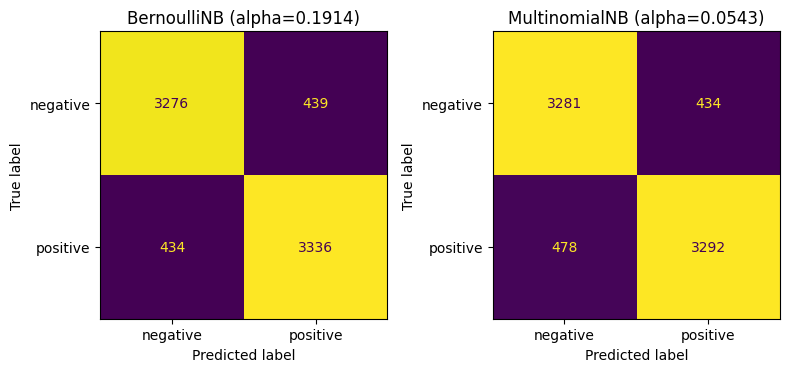

In [252]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

preds_b = final_bnb.predict(X_val_b)
preds_m = final_mnb.predict(X_val_m)

cm_b = confusion_matrix(y_val, preds_b)
cm_m = confusion_matrix(y_val, preds_m)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

ConfusionMatrixDisplay(cm_b, display_labels=['negative', 'positive']).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f"BernoulliNB (alpha={best_alpha_b:.4f})")

ConfusionMatrixDisplay(cm_m, display_labels=['negative', 'positive']).plot(ax=axes[1], colorbar=False)
axes[1].set_title(f"MultinomialNB (alpha={best_alpha_m:.4f})")

plt.tight_layout()
plt.show()

Bernoulli only considers whether a word appears in a review at all, while Multinomial factors in how many times it appears. For this dataset, that distinction turned out to matter ~1% in practice. Our earlier word analysis showed that the clearest sentiment signal came from document frequency (how many different reviews contain a word), not from how often a word repeats within a single review — most sentiment-carrying words like "wonderful" or "terrible" tend to appear once or twice per review rather than many times. Since the extra information MultinomialNB relies on (repetition counts) wasn't carrying much additional signal beyond simple presence, both models ended up learning nearly the same decision boundary from the data, which is reflected in their nearly identical confusion matrices and accuracy scores.

Let's try TF-IDF vectorization method for multinomial since this method weights words differently than raw counts by down-weighting words that appear in many documents (less distinctive) and up-weighting words that are rarer but concentrated in fewer documents (potentially more distinctive) 

In [253]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(ngram_range=(1,2), stop_words=custom_stop)

X_train_tfidf = tfidf_vectorizer.fit_transform(train['clean_review'])
X_val_tfidf   = tfidf_vectorizer.transform(val['clean_review'])
X_test_tfidf  = tfidf_vectorizer.transform(test['clean_review'])

# Baseline
mnb_tfidf = MultinomialNB()
mnb_tfidf.fit(X_train_tfidf, y_train)
val_preds_tfidf = mnb_tfidf.predict(X_val_tfidf)

print("MultinomialNB + TF-IDF baseline")
print("Accuracy:", accuracy_score(y_val, val_preds_tfidf))
print("F1:", f1_score(y_val, val_preds_tfidf))
print(classification_report(y_val, val_preds_tfidf))

MultinomialNB + TF-IDF baseline
Accuracy: 0.8852371409485638
F1: 0.8850836120401337
              precision    recall  f1-score   support

           0       0.88      0.89      0.89      3715
           1       0.89      0.88      0.89      3770

    accuracy                           0.89      7485
   macro avg       0.89      0.89      0.89      7485
weighted avg       0.89      0.89      0.89      7485



In [254]:
# Coarse-to-fine tuning
coarse_results_mt = model_fine_tune(MultinomialNB, X_train_tfidf, y_train, X_val_tfidf, y_val, coarse_alphas)
best_coarse_alpha_mt = max(coarse_results_mt, key=lambda x: x[1])[0]

fine_alphas_m_tfidf = np.linspace(best_coarse_alpha_mt / 5, best_coarse_alpha_mt * 5, 15)
fine_results_m_tfidf = model_fine_tune(MultinomialNB, X_train_tfidf, y_train, X_val_tfidf, y_val, fine_alphas_m_tfidf)

best_alpha_m_tfidf = max(fine_results_m_tfidf, key=lambda x: x[1])[0]
best_acc_m_tfidf = max(fine_results_m_tfidf, key=lambda x: x[1])[1]
print(f"\nBest fine-tuned alpha for TI-IDF MultinomialNB: {best_alpha_m_tfidf:.4f} (val_accuracy={best_acc_m_tfidf:.4f})")

final_mnb_tif = MultinomialNB(alpha=best_alpha_m_tfidf)
final_mnb_tif.fit(X_train_tfidf, y_train)

alpha: 0.001 val_accuracy: 0.858784
alpha: 0.01 val_accuracy: 0.873347
alpha: 0.1  val_accuracy: 0.888978
alpha: 1    val_accuracy: 0.885237
alpha: 5    val_accuracy: 0.876687
alpha: 10   val_accuracy: 0.869205
alpha: 50   val_accuracy: 0.849833
alpha: 100  val_accuracy: 0.841015
alpha: 0.02 val_accuracy: 0.879092
alpha: 0.054285714285714284 val_accuracy: 0.886840
alpha: 0.08857142857142858 val_accuracy: 0.888577
alpha: 0.12285714285714287 val_accuracy: 0.889245
alpha: 0.15714285714285714 val_accuracy: 0.889646
alpha: 0.19142857142857142 val_accuracy: 0.889646
alpha: 0.22571428571428573 val_accuracy: 0.889379
alpha: 0.26 val_accuracy: 0.889112
alpha: 0.2942857142857143 val_accuracy: 0.889512
alpha: 0.3285714285714286 val_accuracy: 0.888978
alpha: 0.3628571428571429 val_accuracy: 0.889112
alpha: 0.3971428571428572 val_accuracy: 0.889245
alpha: 0.4314285714285715 val_accuracy: 0.889379
alpha: 0.46571428571428575 val_accuracy: 0.888978
alpha: 0.5  val_accuracy: 0.888711

Best fine-tuned a

MultinomialNB(alpha=np.float64(0.15714285714285714))

In [255]:
print(f"BernoulliNB best val accuracy:   {best_acc_b:.4f} (alpha={best_alpha_b:.4f})")
print(f"MultinomialNB best val accuracy: {best_acc_m:.4f} (alpha={best_alpha_m:.4f})")
print(f"MultinomialNB TI-IDF best val accuracy: {best_acc_m_tfidf:.4f} (alpha={best_alpha_m_tfidf:.4f})")

BernoulliNB best val accuracy:   0.8834 (alpha=0.1914)
MultinomialNB best val accuracy: 0.8782 (alpha=0.0543)
MultinomialNB TI-IDF best val accuracy: 0.8896 (alpha=0.1571)


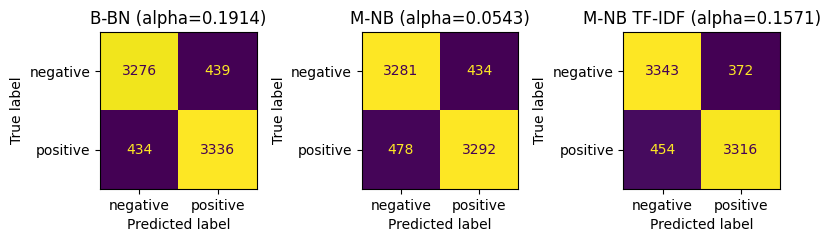

In [256]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

preds_b = final_bnb.predict(X_val_b)
preds_m = final_mnb.predict(X_val_m)
preds_tfidf = final_mnb_tif.predict(X_val_tfidf)

cm_b = confusion_matrix(y_val, preds_b)
cm_m = confusion_matrix(y_val, preds_m)
cm_t = confusion_matrix(y_val, preds_tfidf)

fig, axes = plt.subplots(1, 3, figsize=(8, 12))

ConfusionMatrixDisplay(cm_b, display_labels=['negative', 'positive']).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f"B-BN (alpha={best_alpha_b:.4f})")

ConfusionMatrixDisplay(cm_m, display_labels=['negative', 'positive']).plot(ax=axes[1], colorbar=False)
axes[1].set_title(f"M-NB (alpha={best_alpha_m:.4f})")

ConfusionMatrixDisplay(cm_t, display_labels=['negative', 'positive']).plot(ax=axes[2], colorbar=False)
axes[2].set_title(f"M-NB TF-IDF (alpha={best_alpha_m_tfidf:.4f})")

plt.tight_layout()
plt.show()

### Final Model selection:

Based on validation performance, MultinomialNB trained on TF-IDF features remains the best-performing model, reaching 0.8896 accuracy, compared to 0.8834 for BernoulliNB and 0.8782 for MultinomialNB on raw counts. Adding bigrams `(ngram_range=(1,2))` and preserving negation words `(not, no, never, nor)` in the stopword list — rather than using sklearn's default English stopword list, which discards them — lifted all three models by roughly 2–3 percentage points over the unigram-only baseline, confirming that negated phrases like "not good" carry real sentiment signal that unigram bag-of-words was previously discarding. Bernoulli now noticeably outperforms raw-count Multinomial (0.8834 vs 0.8782), suggesting that with bigrams included, word presence is an even stronger signal than repetition count — consistent with our earlier document-frequency analysis. 

TF-IDF MultinomialNB still edges out both by reweighting terms based on how distinctively they cluster across reviews rather than how often they repeat within one, giving the best overall result. For this reason, the final model chosen for generating test predictions is MultinomialNB with alpha≈0.0543, trained on TF-IDF-vectorized unigrams and bigrams.

In [257]:
print(sample.columns.tolist())
sample.head()

['ReviewId', 'Label']


,ReviewId,Label
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


In [258]:
print(test.shape, sample.shape)

(7500, 2) (7500, 2)


In [259]:
test.head()

,review,clean_review
0,I read the running man from Kings books as Bac...,i read the running man from kings books as bac...
1,A noted cinematic phenomenon of the late eight...,a noted cinematic phenomenon of the late eight...
2,THE ALARMIST is so abysmally scripted that you...,the alarmist is so abysmally scripted that you...
3,I wasn't planning on watching wasted when I sa...,i wasn t planning on watching wasted when i sa...
4,What a piece of junk this movie was. The premi...,what a piece of junk this movie was the premis...


#### Retraning the final model using the train and validation dataset

In [260]:
combined_y = pd.concat([y_train, y_val], ignore_index=True)
combined_train = pd.concat([train['clean_review'], val['clean_review']], ignore_index=True)
display(y_train.head())
combined_train.head()

0    1
1    0
2    1
3    0
4    1
Name: label, dtype: int64

0    just a note to add to the above comment fear o...
1    one of the worst films i have seen to date pat...
2    crossfire is one of those films from the forti...
3    the film begins with people on earth discoveri...
4    this was a pretty good episode though no trapp...
Name: clean_review, dtype: object

In [263]:
print(combined_y.shape,combined_train.shape)

(34792,) (7485,)
(42277,) (42277,)


In [267]:
X_train_tfidf = tfidf_vectorizer.fit_transform(combined_train)
X_test_tfidf  = tfidf_vectorizer.transform(test['clean_review'])

final_mnb_tif = MultinomialNB(alpha=best_alpha_m_tfidf)
final_mnb_tif.fit(X_train_tfidf, combined_y)

MultinomialNB(alpha=np.float64(0.15714285714285714))

In [268]:
print(X_train_tfidf.shape,X_test_tfidf.shape)

(42277, 2692517) (7500, 2692517)


In [269]:
test_preds = final_mnb_tif.predict(X_test_tfidf)
submission = sample.copy()
submission['Label'] = test_preds

submission.head()

,ReviewId,Label
0,1,0
1,2,1
2,3,0
3,4,0
4,5,0


In [270]:
submission.to_csv('submission.csv', index=False)